In [2]:
pip install --upgrade nbconvert jupyter


  Attempting uninstall: nbconvert
    Found existing installation: nbconvert 7.16.4
    Uninstalling nbconvert-7.16.4:
      Successfully uninstalled nbconvert-7.16.4
  Attempting uninstall: jupyter
    Found existing installation: jupyter 1.0.0
    Uninstalling jupyter-1.0.0:
      Successfully uninstalled jupyter-1.0.0
Note: you may need to restart the kernel to use updated packages.


In [116]:
#import necessary libraries
import pandas as pd
import numpy as np
import json
import seaborn as sns
import matplotlib.pyplot as plt

# **Load Dataset**

In [117]:
#Load dataset
from datasets import load_dataset
ag_news = load_dataset("sh0416/ag_news")
ag_news

DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'description'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['label', 'title', 'description'],
        num_rows: 7600
    })
})

In [118]:
# Split training set into train and validation
split = ag_news['train'].train_test_split(test_size=0.1, seed=42)
train_dataset = split['train']  # 90% of training set
val_dataset   = split['test']   # 10% of training set

# Test set
test_dataset  = ag_news['test']


# **Data Analysis**

In [119]:
# Convert to pandas
train_df = pd.DataFrame(train_dataset)
test_df = pd.DataFrame(test_dataset)
val_df=pd.DataFrame(val_dataset)

In [120]:
# Display rows of each dataset
print("Train set", train_df.head())
print("Test set",test_df.head())
print("Validation set", val_df.head())

Train set    label                                              title  \
0      1  Despair and Anger in Small Russian Town After ...   
1      4           Bob Evans, mainframe pioneer, dies at 77   
2      2         Agassi Brushes Bjorkman Aside in Stockholm   
3      4           UK scientists bring hydrogen cars closer   
4      2             Chelsea beats defending champion Porto   

                                         description  
0   BESLAN, Russia (Reuters) - The killing of mor...  
1  Evans led a team that developed a new class of...  
2   STOCKHOLM (Reuters) - Andre Agassi brushed pa...  
3  British scientists have used nanotechnology to...  
4  Jose Mourinho #39;s Chelsea outplayed the team...  
Test set    label                                              title  \
0      3                  Fears for T N pension after talks   
1      4  The Race is On: Second Private Team Sets Launc...   
2      4      Ky. Company Wins Grant to Study Peptides (AP)   
3      4      Predic

In [121]:
# Display a concise summary of each datasets

print("Train dataset info")
train_df.info()

print("\nValidation dataset info")
val_df.info()

print("\nTest dataset info")
test_df.info()




Train dataset info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108000 entries, 0 to 107999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   label        108000 non-null  int64 
 1   title        108000 non-null  object
 2   description  108000 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.5+ MB

Validation dataset info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   label        12000 non-null  int64 
 1   title        12000 non-null  object
 2   description  12000 non-null  object
dtypes: int64(1), object(2)
memory usage: 281.4+ KB

Test dataset info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7600 entries, 0 to 7599
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   label    

In [122]:
# Check and display the number of missing (null) values in each column
print("Null values in train set", train_df.isnull().sum())
print("\nNull values in test set", test_df.isnull().sum())
print("\nNull values in validation set", val_df.isnull().sum())


Null values in train set label          0
title          0
description    0
dtype: int64

Null values in test set label          0
title          0
description    0
dtype: int64

Null values in validation set label          0
title          0
description    0
dtype: int64


In [123]:
#Showcasing unique values in Ag News dataset
train_df['label'].unique()

array([1, 4, 2, 3])

In [124]:
# Display the number of rows and columns in the training dataset
print("Train shape:", train_df.shape)

# Display the number of rows and columns in the test dataset
print("Test shape:", test_df.shape)

# Display the number of rows and columns in the validation dataset
print("Validation shape:", val_df.shape)


Train shape: (108000, 3)
Test shape: (7600, 3)
Validation shape: (12000, 3)


# **Exploratory Data Analysis**

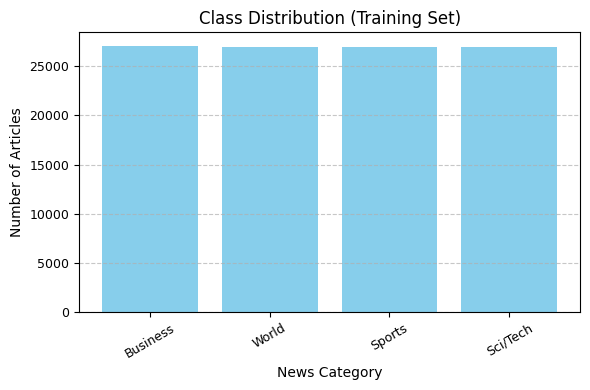

In [125]:
import matplotlib.pyplot as plt

# Mapping numeric class labels to their corresponding news category names
label_map = {
    1: "World",
    2: "Sports",
    3: "Business",
    4: "Sci/Tech"
}

# Count the number of articles in each class from the training dataset
train_counts = train_df["label"].value_counts()

# Create a bar chart to visualize class distribution
plt.figure(figsize=(6, 4))

# Plot bar chart using category names instead of numeric labels
plt.bar(
    [label_map[i] for i in train_counts.index],
    train_counts.values,
    color='skyblue'
)

# Label the x-axis
plt.xlabel("News Category", fontsize=10)

# Label the y-axis
plt.ylabel("Number of Articles", fontsize=10)

# Set the title of the plot
plt.title("Class Distribution (Training Set)", fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=30, fontsize=9)

# Set font size for y-axis labels
plt.yticks(fontsize=9)

# Add grid lines to the y-axis for easier comparison
plt.grid(axis="y", linestyle='--', alpha=0.7)

# Adjust layout to prevent overlapping elements
plt.tight_layout()

# Display the plot
plt.show()


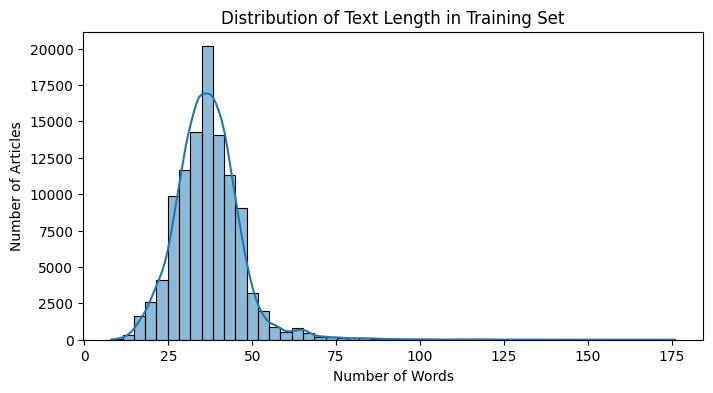

In [126]:
# Plot distribution of word counts in combined title and description
plt.figure(figsize=(8,4))
sns.histplot(
    (train_df['title'] + train_df['description']).apply(lambda x: len(x.split())),
    bins=50,
    kde=True
)

# Set the x label
plt.xlabel("Number of Words")

# Set the y label
plt.ylabel("Number of Articles")

# Set the title
plt.title("Distribution of Text Length in Training Set")

# Display the plot
plt.show()


In [127]:
train_df

,label,title,description
0,1,Despair and Anger in Small Russian Town After ...,"BESLAN, Russia (Reuters) - The killing of mor..."
1,4,"Bob Evans, mainframe pioneer, dies at 77",Evans led a team that developed a new class of...
2,2,Agassi Brushes Bjorkman Aside in Stockholm,STOCKHOLM (Reuters) - Andre Agassi brushed pa...
3,4,UK scientists bring hydrogen cars closer,British scientists have used nanotechnology to...
4,2,Chelsea beats defending champion Porto,Jose Mourinho #39;s Chelsea outplayed the team...
...,...,...,...
107995,1,Haitians Left in Devasting Wake of Jeanne,The death toll across Haiti from the weekend d...
107996,2,Ask Walker about NU #39;s special day,"MADISON, Wis. -- Northwestern #39;s special te..."
107997,2,West Indies Hold Up England March,James Anderson took both wickets to fall as En...
107998,1,"UN council mulls Sudan resolution, US to speak...",AFP - The UN Security Council was to discuss a...


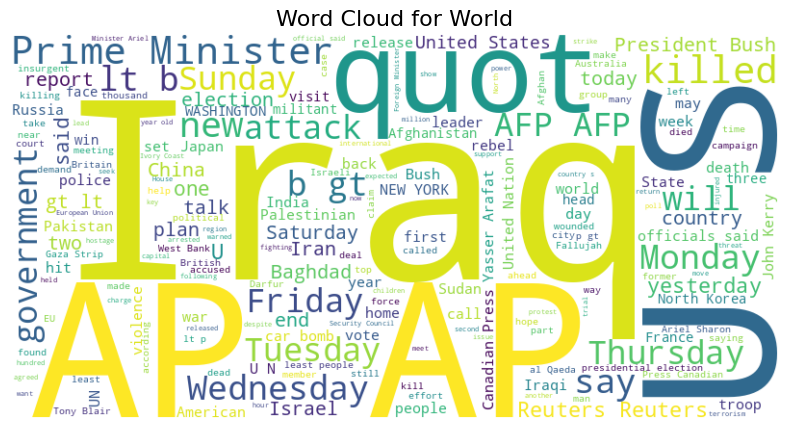

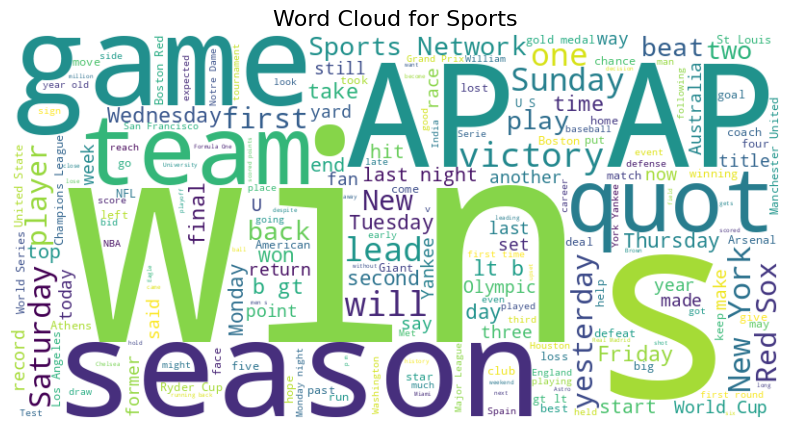

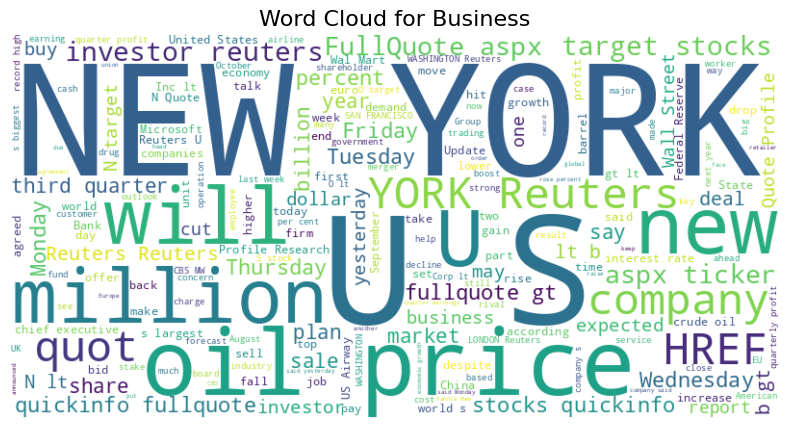

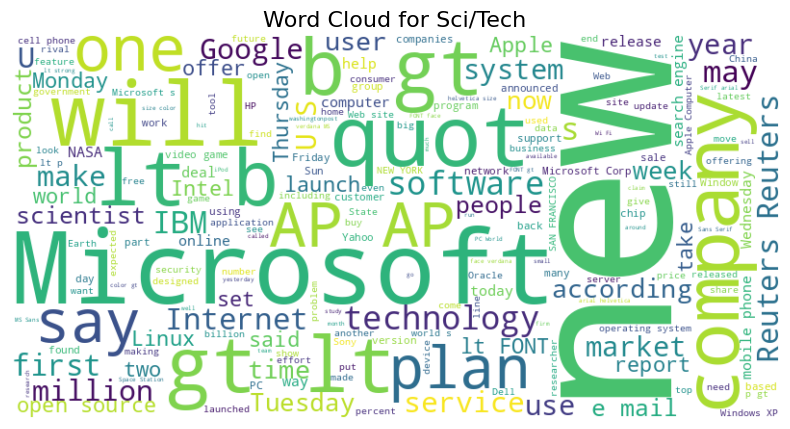

In [128]:
from wordcloud import WordCloud

# Map numeric labels to category names
label_map = {
    1: "World",
    2: "Sports",
    3: "Business",
    4: "Sci/Tech"
}

# Loop through each label/category in the training set
for label, group in train_df.groupby('label'):
    # Combine all text in 'title_description' column (already cleaned if you applied preprocess)
    text = " ".join(group['title'] + " " + group['description'])

    # Generate the word cloud
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white'
    ).generate(text)

    # Display the word cloud
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud for {label_map[label]}", fontsize=16)
    plt.show()


# **Text Preprocessing**

In [129]:
import nltk

# Download required resources
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt')  # sometimes required for tokenization
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [130]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Initialize the lemmatizer to reduce words to their base form
lemmatizer = WordNetLemmatizer()

# Load English stopwords
stop_words = set(stopwords.words('english'))

# Function to combine title and description into a single column
def combine_column(df):
    df['title_description'] = df['title'] + " " + df['description']
    df.drop(columns=['title', 'description'], inplace=True)

    return df

# Function to preprocess text data
def preprocess(text):
    # Check if input is a string and split into words
    if isinstance(text, str):
        words = text.split()
    else:
        words = text

    cleaned_text = []

    # Process each word
    for w in words:
        w_lower = w.lower()                 # Convert word to lowercase
        if w_lower not in stop_words:       # Remove stopwords
            w_lemma = lemmatizer.lemmatize(w_lower)  # Lemmatize the word
            cleaned_text.append(w_lemma)

    # Join cleaned words back into a single string
    return " ".join(cleaned_text)




In [131]:
# Apply cleaning and preprocessing function to the training dataset
train_df = combine_column(train_df)
train_df['title_description'] = train_df['title_description'].apply(preprocess)

# Display first few rows after preprocessing
train_df.head()


,label,title_description
0,1,"despair anger small russian town siege beslan,..."
1,4,"bob evans, mainframe pioneer, dy 77 evans led ..."
2,2,agassi brush bjorkman aside stockholm stockhol...
3,4,uk scientist bring hydrogen car closer british...
4,2,chelsea beat defending champion porto jose mou...


In [132]:
# Apply cleaning and preprocessing to test data
test_df = combine_column(test_df)
test_df['title_description'] = test_df['title_description'].apply(preprocess)

test_df.head()

,label,title_description
0,3,fear n pension talk union representing worker ...
1,4,race on: second private team set launch date h...
2,4,ky. company win grant study peptide (ap) ap - ...
3,4,prediction unit help forecast wildfire (ap) ap...
4,4,calif. aim limit farm-related smog (ap) ap - s...


In [133]:
# Apply cleaning and preprocessing to validation data
val_df = combine_column(val_df)
val_df['title_description'] = val_df['title_description'].apply(preprocess)

val_df.head()

,label,title_description
0,1,bangladesh paralysed strike opposition activis...
1,2,desiring stability redskin coach joe gibbs exp...
2,1,putin #39;s power play make russia safer? outw...
3,4,u2 pitch apple new itunes ad airing baseball g...
4,1,african tv beheading blunder public broadcaste...


In [134]:
# Import TF-IDF vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),
    max_features=20000,
    min_df=3,
    max_df=0.95,
    stop_words='english'
)

# Transform text data into TF-IDF features
X_train_vec = vectorizer.fit_transform(train_df['title_description'])
X_val_vec   = vectorizer.transform(val_df['title_description'])
X_test_vec  = vectorizer.transform(test_df['title_description'])

In [135]:
# Extract labels
y_train = train_df['label'].values
y_val = val_df['label'].values
y_test= test_df['label'].values

In [136]:
# Display label statistics
print(train_df['label'].unique())
print(train_df['label'].dtype)
print(train_df['label'].value_counts())

y=train_df['label']



[1 4 2 3]
int64
label
3    27100
1    26991
2    26966
4    26943
Name: count, dtype: int64


In [137]:
# Number of unique classes in the training labels
num_classes = len(np.unique(y_train))
from sklearn.preprocessing import OneHotEncoder

# Reshape labels to 2D (required by sklearn)
y_train_reshaped = y_train.reshape(-1, 1)
y_val_reshaped   = y_val.reshape(-1, 1)
y_test_reshaped  = y_test.reshape(-1, 1)

# Create encoder
encoder = OneHotEncoder(sparse_output=False)

# Fit ONLY on training data
y_train_onehot = encoder.fit_transform(y_train_reshaped)

# Transform validation and test
y_val_onehot  = encoder.transform(y_val_reshaped)
y_test_onehot = encoder.transform(y_test_reshaped)

# **Training and Evaluation**

In [138]:
#Define softmax function
import numpy as np
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [139]:
import numpy as np
import matplotlib.pyplot as plt

def gradient_descent_weighted(
    X_train, y_train,
    X_val=None, y_val=None,
    lr=0.01,
    epochs=20,
    batch_size=1024,
    lambda_reg=1e-5
):
    # Get number of features, classes, and samples
    n_features = X_train.shape[1]
    n_classes = y_train.shape[1]
    n_samples = X_train.shape[0]

    # Initialize weights and bias
    w = np.zeros((n_features, n_classes))
    b = np.zeros((1, n_classes))

    # Store accuracy values
    train_acc_history = []
    val_acc_history = []

    # Training loop
    for epoch in range(epochs):
        print(f"Epoch {epoch + 1}/{epochs}")

        # Mini-batch gradient descent
        for start in range(0, n_samples, batch_size):
            end = start + batch_size
            X_batch = X_train[start:end]
            y_batch = y_train[start:end]

            # Forward pass
            z = X_batch.dot(w) + b
            exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
            y_pred = exp_z / np.sum(exp_z, axis=1, keepdims=True)

            # Compute error
            error = y_pred - y_batch

            # Compute gradients
            dw = X_batch.T.dot(error) / X_batch.shape[0]
            dw += lambda_reg * w
            db = np.sum(error, axis=0, keepdims=True) / X_batch.shape[0]

            # Update parameters
            w -= lr * dw
            b -= lr * db

        # Calculate training accuracy
        y_train_pred = np.argmax(X_train.dot(w) + b, axis=1)
        y_true_train = np.argmax(y_train, axis=1)
        train_acc = np.mean(y_train_pred == y_true_train)
        train_acc_history.append(train_acc)

        # Calculate validation accuracy if provided
        if X_val is not None and y_val is not None:
            y_val_pred = np.argmax(X_val.dot(w) + b, axis=1)
            y_true_val = np.argmax(y_val, axis=1)
            val_acc = np.mean(y_val_pred == y_true_val)
            val_acc_history.append(val_acc)
            print(f"  Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
        else:
            print(f"  Train Acc: {train_acc:.4f}")

    # Plot training and validation accuracy
    epochs_range = range(1, epochs + 1)
    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, train_acc_history, label="Training Accuracy")

    if val_acc_history:
        plt.plot(epochs_range, val_acc_history, label="Validation Accuracy")

    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy (Logistic Regression)")
    plt.legend()
    plt.grid(True)
    plt.show()

    return w, b, train_acc_history, val_acc_history



In [140]:
def predict(X, w, b):
    # Compute linear scores
    z = X.dot(w) + b

    # Apply softmax
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    probs = exp_z / np.sum(exp_z, axis=1, keepdims=True)

    # Return predicted class labels
    return np.argmax(probs, axis=1)


In [141]:
print(X_train_vec .shape[0] )
print(y_train.shape[0])


108000
108000


In [142]:
print("Train labels:", np.unique(y_train))
print("Val labels:", np.unique(y_val))
print("Test labels:", np.unique(y_test))


Train labels: [1 2 3 4]
Val labels: [1 2 3 4]
Test labels: [1 2 3 4]


Epoch 1/40
  Train Acc: 0.8117 | Val Acc: 0.8022
Epoch 2/40
  Train Acc: 0.8613 | Val Acc: 0.8570
Epoch 3/40
  Train Acc: 0.8698 | Val Acc: 0.8658
Epoch 4/40
  Train Acc: 0.8717 | Val Acc: 0.8662
Epoch 5/40
  Train Acc: 0.8721 | Val Acc: 0.8652
Epoch 6/40
  Train Acc: 0.8719 | Val Acc: 0.8656
Epoch 7/40
  Train Acc: 0.8720 | Val Acc: 0.8663
Epoch 8/40
  Train Acc: 0.8721 | Val Acc: 0.8659
Epoch 9/40
  Train Acc: 0.8722 | Val Acc: 0.8655
Epoch 10/40
  Train Acc: 0.8722 | Val Acc: 0.8658
Epoch 11/40
  Train Acc: 0.8720 | Val Acc: 0.8660
Epoch 12/40
  Train Acc: 0.8721 | Val Acc: 0.8662
Epoch 13/40
  Train Acc: 0.8722 | Val Acc: 0.8662
Epoch 14/40
  Train Acc: 0.8721 | Val Acc: 0.8663
Epoch 15/40
  Train Acc: 0.8721 | Val Acc: 0.8665
Epoch 16/40
  Train Acc: 0.8721 | Val Acc: 0.8667
Epoch 17/40
  Train Acc: 0.8721 | Val Acc: 0.8667
Epoch 18/40
  Train Acc: 0.8721 | Val Acc: 0.8663
Epoch 19/40
  Train Acc: 0.8723 | Val Acc: 0.8668
Epoch 20/40
  Train Acc: 0.8724 | Val Acc: 0.8669
Epoch 21/

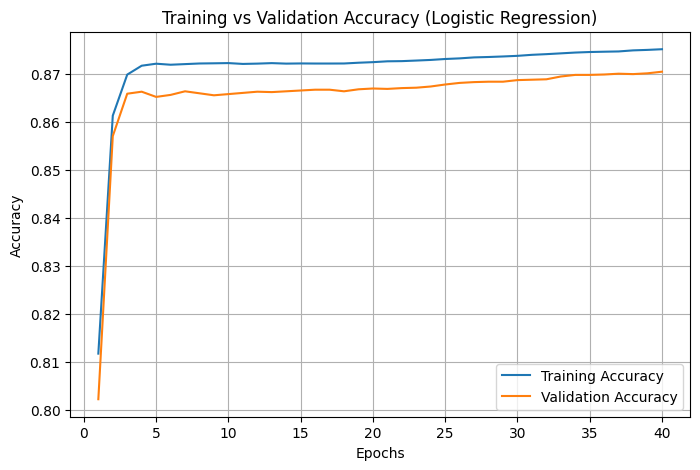

In [143]:
import numpy as np

# Define hyperparameter grid
lr = 0.1
batch_size = 1024
lambda_reg = 0.001
epochs   = 40


w, b, train_acc, val_acc = gradient_descent_weighted(
        X_train_vec , y_train_onehot,
        X_val=X_val_vec,
        y_val=y_val_onehot,
        lr=lr,
        epochs=epochs,
        batch_size=batch_size,
       lambda_reg=lambda_reg
      )

In [144]:

# Make predictions
y_pred = np.argmax(X_test_vec.dot(w) + b, axis=1)
y_true_test = np.argmax(y_test_onehot, axis=1)

In [145]:
from sklearn.metrics import classification_report, confusion_matrix

print("\nClassification Report:")
print(classification_report(y_true_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.89      0.88      1900
           1       0.89      0.97      0.93      1900
           2       0.86      0.80      0.83      1900
           3       0.85      0.82      0.83      1900

    accuracy                           0.87      7600
   macro avg       0.87      0.87      0.87      7600
weighted avg       0.87      0.87      0.87      7600



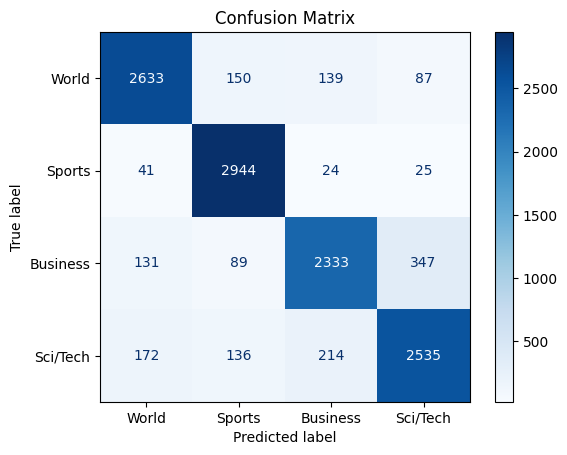

In [146]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Map class indices to category names
index_to_label_ag = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}

# Predict on validation set
y_val_pred = np.argmax(X_val_vec.dot(w) + b, axis=1)

# Convert one-hot validation labels to class indices
y_true_val = np.argmax(y_val_onehot, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_true_val, y_val_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(index_to_label_ag.values()))
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


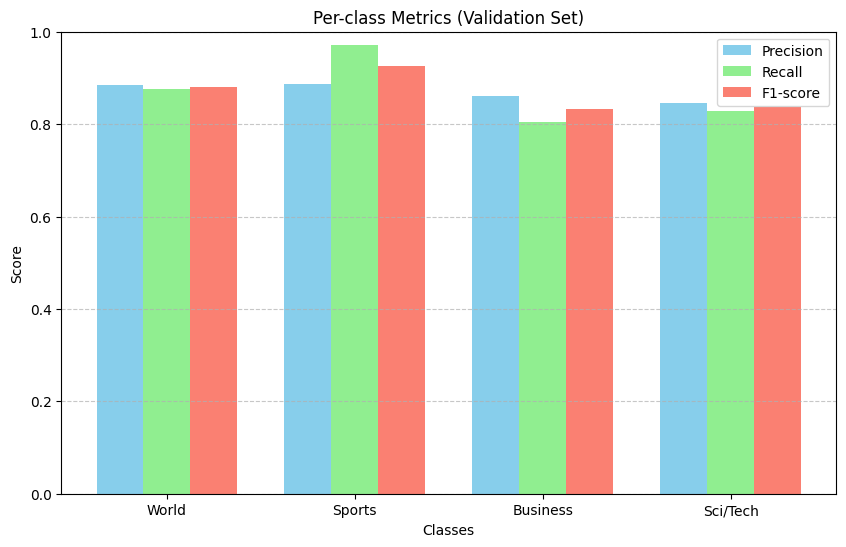

In [147]:
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt
import numpy as np

# Ensure validation predictions and true labels are class indices
y_val_pred = np.argmax(X_val_vec.dot(w) + b, axis=1)
y_true_val = np.argmax(y_val_onehot, axis=1)

# Compute per-class metrics
precision, recall, f1, _ = precision_recall_fscore_support(y_true_val, y_val_pred, average=None)

# Define class names
index_to_label_ag = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}
classes = list(index_to_label_ag.values())

# Set bar width and positions
x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(10,6))
plt.bar(x - width, precision, width, label='Precision', color='skyblue')
plt.bar(x, recall, width, label='Recall', color='lightgreen')
plt.bar(x + width, f1, width, label='F1-score', color='salmon')

plt.xticks(x, classes)
plt.ylim(0, 1)
plt.xlabel("Classes")
plt.ylabel("Score")
plt.title("Per-class Metrics (Validation Set)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


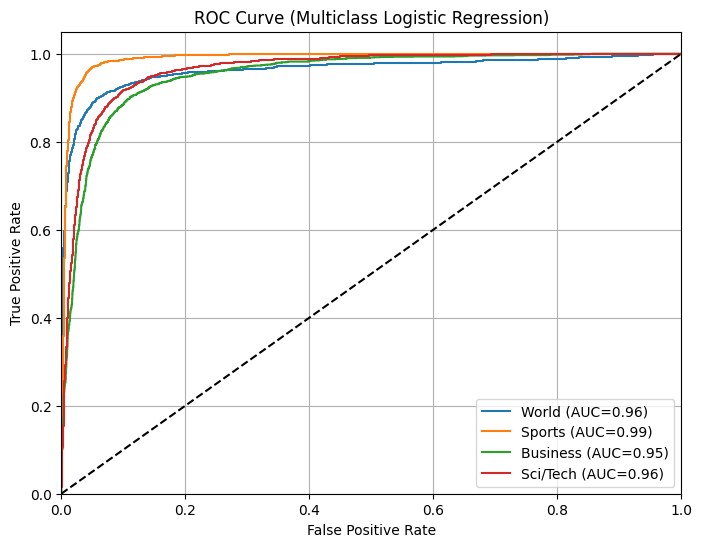

In [148]:
from sklearn.preprocessing import label_binarize

# Shift labels from 1-4 → 0-3
y_test_zero_based = y_test - 1
y_test_onehot = label_binarize(y_test_zero_based, classes=[0, 1, 2, 3])

# Compute predicted probabilities
z = X_test_vec.dot(w) + b
exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
y_prob = exp_z / np.sum(exp_z, axis=1, keepdims=True)

# Plot ROC and AUC
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

n_classes = y_test_onehot.shape[1]
plt.figure(figsize=(8,6))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_onehot[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{index_to_label_ag[i]} (AUC={roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Multiclass Logistic Regression)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [149]:
# Create a list of sample news articles for testing the trained model
sample_texts_ag = [
    # World
    {
        "title": "National elections spark debates on economic and foreign policy",
        "description": "Candidates outline their visions for the next government term."
    },
    {
        "title": "Peace talks resume between conflicting nations in the Middle East",
        "description": "Diplomats aim to reach an agreement to end long-standing hostilities."
    },

    # Sports
    {
        "title": "Local basketball team wins state championship after thrilling overtime",
        "description": "The championship game went into overtime, and the local team clinched the victory."
    },
    {
        "title": "Football league announces schedule changes for the upcoming season",
        "description": "Teams will face new opponents in revised match fixtures."
    },

    # Business
    {
        "title": "Stock markets surge as major companies report record earnings",
        "description": "Investors react positively to quarterly financial results across industries."
    },
    {
        "title": "Trading has been one to most successful business",
        "description": "The investment will fund research in sustainable and renewable technologies."
    },

    # Sci/Tech
    {
        "title": "Tech company announces launch of AI-powered software platform",
        "description": "The new platform aims to automate workflows and enhance productivity across industries."
    },
    {
        "title": "Scientists discover new exoplanet orbiting nearby star",
        "description": "Astronomers use advanced telescopes to identify potential habitable planets."
    }
]
# Mapping predicted class indices back to category names
index_to_label_ag = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}

# Convert sample news list into a DataFrame
sample_df = pd.DataFrame(sample_texts_ag)


# Combine title and description into a single column
sample_texts_combined = combine_column(sample_df)
sample_df_copy=sample_texts_combined.copy()
# Apply text preprocessing to the combined text
sample_texts_combined['title_description'] = sample_df['title_description'].apply(preprocess)

# Convert sample text into TF-IDF feature vectors
X_sample = vectorizer.transform(sample_df['title_description']).toarray()

# Predict class indices using the trained model
preds = predict(X_sample, w, b)

# Convert predicted indices into category names
predicted_labels = [index_to_label_ag[i] for i in preds]

# Print each news article with its predicted category
for title, label in zip(sample_df_copy['title_description'], predicted_labels):
    print(f"Title: {title}")
    print(f"Predicted Category: {label}\n")


Title: National elections spark debates on economic and foreign policy Candidates outline their visions for the next government term.
Predicted Category: World

Title: Peace talks resume between conflicting nations in the Middle East Diplomats aim to reach an agreement to end long-standing hostilities.
Predicted Category: World

Title: Local basketball team wins state championship after thrilling overtime The championship game went into overtime, and the local team clinched the victory.
Predicted Category: Sports

Title: Football league announces schedule changes for the upcoming season Teams will face new opponents in revised match fixtures.
Predicted Category: Sports

Title: Stock markets surge as major companies report record earnings Investors react positively to quarterly financial results across industries.
Predicted Category: Business

Title: Trading has been one to most successful business The investment will fund research in sustainable and renewable technologies.
Predicted Ca